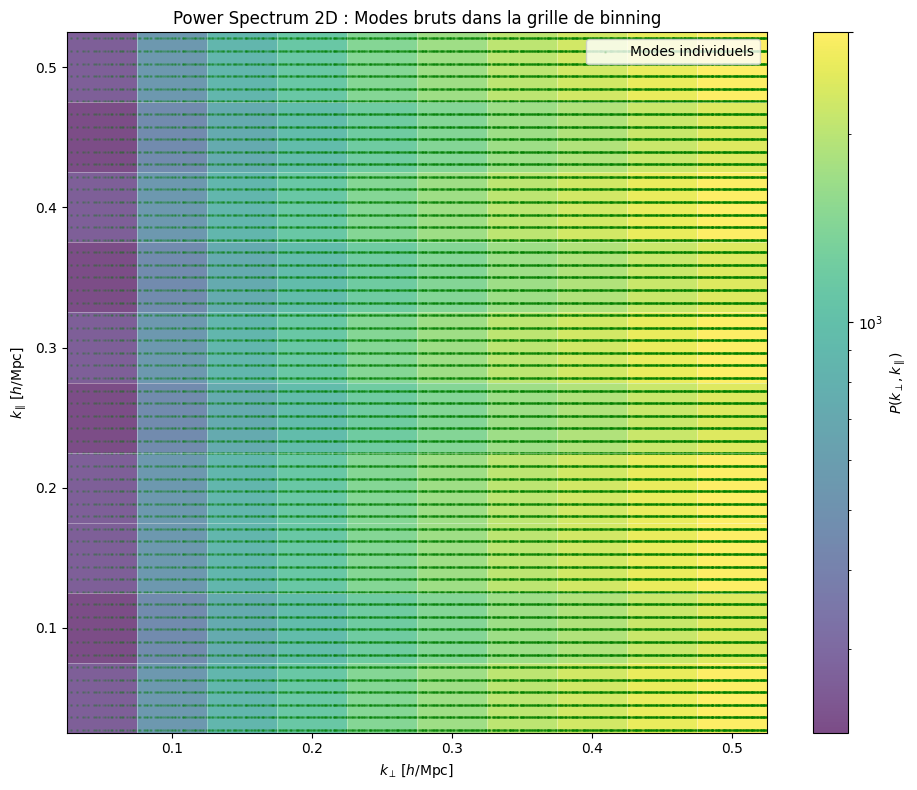

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker

# --- 1. Ta fonction modifiée et corrigée ---
def compute_simulated_data(box_len, hiidim):
    """
    Génère des données simulées.
    Correction : Les boucles for imbriquées étaient incorrectes.
    J'ai aussi ajouté une 'valeur' simulée pour le Power Spectrum.
    """
    # k_fundamental
    kf = 2 * np.pi / box_len
    
    # Listes pour stocker les résultats
    k_perp_list = []
    k_par_list = []
    power_list = []

    # Le range doit aller jusqu'à hiidim//2 inclus, et commencer à 0 ou 1 selon ta convention
    # Pour un PS 2D, i1 et i2 définissent k_perp, i3 définit k_par
    for i1 in range(1, hiidim // 2 + 1):
        for i2 in range(1, hiidim // 2 + 1):
            for i3 in range(1, hiidim // 2 + 1):
                
                # Calcul des composantes k
                kx = i1 * kf
                ky = i2 * kf
                kz = i3 * kf
                
                k_perp = np.sqrt(kx**2 + ky**2)
                k_par = kz
                
                # Modèle de Power Spectrum bidon pour la démo (ex: loi de puissance)
                # On évite k=0
                k_mag = np.sqrt(k_perp**2 + k_par**2)
                if k_mag == 0:
                    power = 0
                else:
                    power = 1.0 / (k_mag**3 + 0.1) # Exemple arbitraire
                k_perp_list.append(k_perp)
                k_par_list.append(k_par)
                power_list.append(power)
                
    return np.array(k_perp_list), np.array(k_par_list), np.array(power_list)

# --- 2. Paramètres de la simulation ---
box_len = 700.0 # Mpc/h, exemple
hiidim = 350    # Résolution de la grille

# Génération des données "brutes" (chaque mode de Fourier)
kperp_raw, kpar_raw, power_raw = compute_simulated_data(box_len, hiidim)

# --- 3. Définition de ta grille de binning ---
k_edges = np.arange(0.025, 0.575, 0.05)
# Centre des bins pour le plot final
k_centers = (k_edges[:-1] + k_edges[1:]) / 2

# --- 4. Calcul du Power Spectrum 2D binné ---
# On utilise histogram2d pour faire la moyenne par bin
mode_count, _, _ = np.histogram2d(kperp_raw, kpar_raw, bins=[k_edges, k_edges])
power_sum, _, _ = np.histogram2d(kperp_raw, kpar_raw, bins=[k_edges, k_edges], weights=power_raw)

# Moyenne (en évitant la division par zéro)
with np.errstate(divide='ignore', invalid='ignore'):
    power_2d = mode_count
    power_2d[mode_count == 0] = 0 # No modes, no power

# --- 5. Le Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# A. Affichage du Power Spectrum 2D binné (le fond)
X, Y = np.meshgrid(k_edges, k_edges)
f_min = power_2d[power_2d > 0].min() if np.any(power_2d > 0) else 1e-10
f_max = power_2d.max()

pcm = ax.pcolormesh(X, Y, power_2d.T, # .T car histogram2d inverse x et y
                    norm=colors.LogNorm(vmin=f_min, vmax=f_max),
                    cmap='viridis', shading='flat', alpha=0.7)

# B. Affichage de la grille de binning (les "carreaux")
for edge in k_edges:
    ax.axhline(edge, color='white', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(edge, color='white', linestyle='-', linewidth=0.5, alpha=0.5)

# C. L'élément clé : Afficher CHACUN des points bruts
# On utilise scatter pour tracer tous les modes individuels
ax.scatter(kperp_raw, kpar_raw, color='green', s=1, alpha=0.1, label='Modes individuels')

# Configuration des axes
ax.set_xlabel(r'$k_{\perp} \, [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$k_{\parallel} \, [h/\mathrm{Mpc}]$')
ax.set_title(r'Power Spectrum 2D : Modes bruts dans la grille de binning')
ax.set_xlim(k_edges[0], k_edges[-1])
ax.set_ylim(k_edges[0], k_edges[-1])
ax.set_aspect('equal') # Pour que les carreaux soient carrés si possible
ax.legend(loc='upper right')

# --- D. Colorbar avec la gestion propre du max (ton problème précédent) ---
cbar = fig.colorbar(pcm, ax=ax, label=r'$P(k_{\perp}, k_{\parallel})$')

# Force l'affichage du max
ticks = list(cbar.ax.yaxis.get_majorticklocs())
ticks = [t for t in ticks if t < f_max] 
ticks.append(f_max)

cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
# Assure que le label max n'est pas coupé
cbar.ax.set_ylim(f_min, f_max)

plt.tight_layout()
plt.show()

In [10]:
def compute_input_params(theta, seed = 1234,box_len=700, hiidim=350):
    user_params = p21c.SimulationOptions(
        BOX_LEN=box_len,
        HII_DIM=hiidim,
        DIM=hiidim*3,
        N_THREADS=16,
        SAMPLER_MIN_MASS= 1e10,
        DEXM_OPTIMIZE_MINMASS=3e11,
    )

    astro_options = p21c.AstroOptions(
        USE_TS_FLUCT=False,
        USE_X_RAY_HEATING=False,
        INHOMO_RECO=True,
        M_MIN_in_Mass=True
    )

    cosmo_params = p21c.CosmoParams(
        hlittle=0.6766,
        OMm=0.30964,
        OMb=0.04897,
        POWER_INDEX=0.9665,
        SIGMA_8=0.8102
    )
    astro_params = p21c.AstroParams(
        ALPHA_STAR=theta['ALPHA_STAR'], 
        F_STAR10=theta['F_STAR10'],
        F_ESC10=theta['F_ESC10'],
        ALPHA_ESC=theta['ALPHA_ESC'],
        M_TURN=theta['M_TURN'],
        t_STAR=theta['t_STAR'],
        L_X=theta['L_X'], #useless     
        NU_X_THRESH=theta['NU_X_THRESH'],  #useless  
        NU_X_BAND_MAX=2000.0, # Max of the band, don't moove this one ! 
    )
    inputs = p21c.InputParameters(
        cosmo_params=cosmo_params,
        astro_options=astro_options,
        astro_params=astro_params,
        simulation_options=user_params,
        random_seed=seed,
        node_redshifts=p21c.wrapper.inputs.get_logspaced_redshifts(
            min_redshift=6.00,
            z_step_factor=1.02,
            max_redshift=8.5,))

    return inputs

In [ ]:
theta_fixed = {
    'ALPHA_STAR': 0.5, 
    'F_STAR10': -1.3,
    'F_ESC10': -1,
    'ALPHA_ESC': -0.5,
    'M_TURN': 8.69, 
    't_STAR': 0.5,
    'L_X': 40.5,             
    'NU_X_THRESH': 500.0,     
    }
compute_input_params(theta_fixed)

NameError: name 'inputs' is not defined

PS1_PS2_Data/Pk_PS2_151.0_165.9.txt


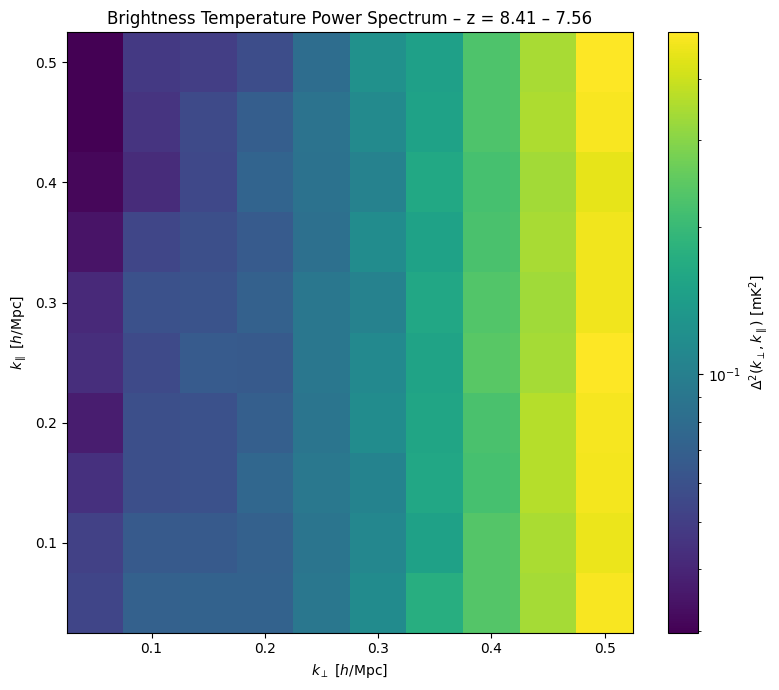

PS1_PS2_Data/Pk_PS2_166.0_180.9.txt


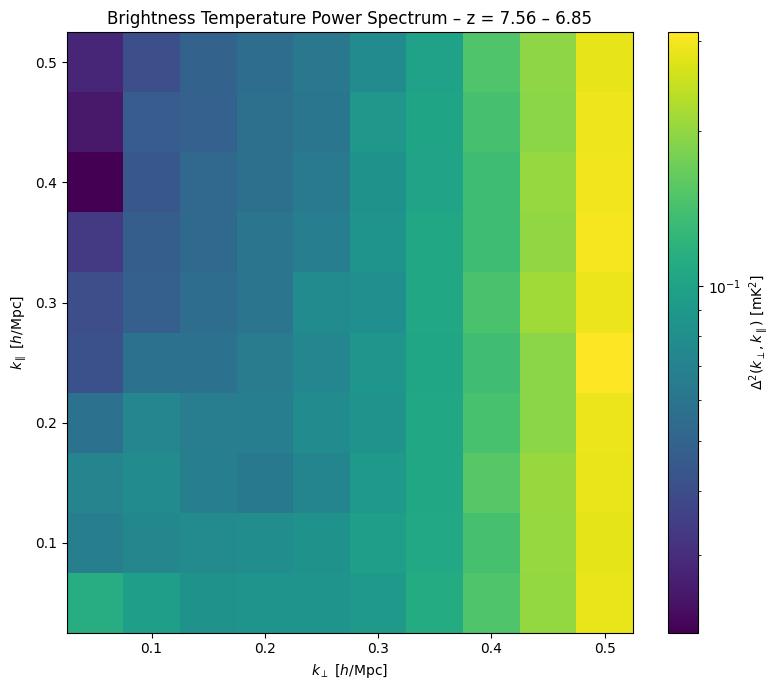

PS1_PS2_Data/Pk_PS2_181.0_195.9.txt


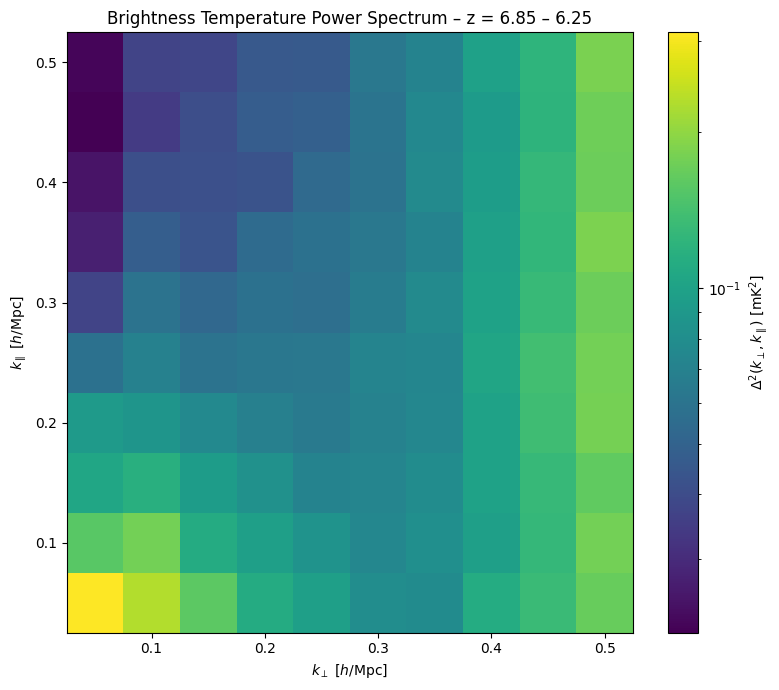

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm,Normalize

# Chargement des axes
kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/Pk_PS2_*.txt"))
z_ranges = [
    "z = 8.41 – 7.56",
    "z = 7.56 – 6.85",
    "z = 6.85 – 6.25"
]
for i,f in enumerate(files):
    data = np.loadtxt(f)
    print(f)
    data = data  # Soustraction du bruit
    plt.figure(figsize=(8, 7))
    
    # pcolormesh avec shading='flat' ou 'nearest' affiche les données brutes
    # On définit les limites des axes pour correspondre aux vecteurs k  
    pcm = plt.pcolormesh(kperp, kpar, data, 
                         norm=LogNorm(vmin=data[data>0].min(), vmax=data[data>0].max()),
                         cmap='viridis')
    plt.colorbar(pcm, label=r'$\Delta^2(k_\perp, k_\parallel)$ [mK$^2$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'Brightness Temperature Power Spectrum – {z_ranges[i]}')    
    plt.tight_layout()
    plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))
files_noise = sorted(glob.glob("PS1_PS2_Data/Pk_PS_averaged_noise_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_err_list = []
ps2_average_noise_list = []
for i, f in enumerate(files):
    data_std = np.loadtxt(f)
    data_average_noise = np.loadtxt(files_noise[i])
    ps2_true_err_list.append(data_std)
    ps2_average_noise_list.append(data_average_noise)

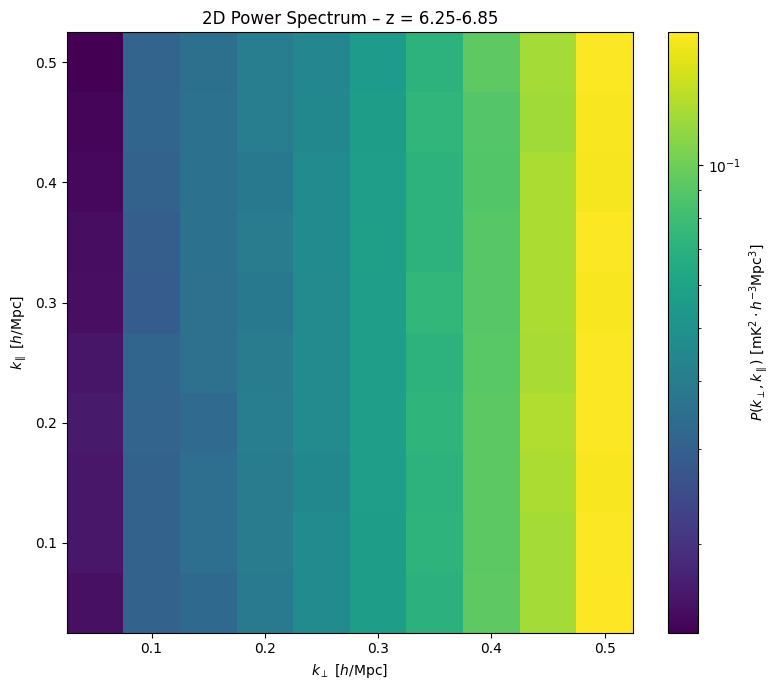

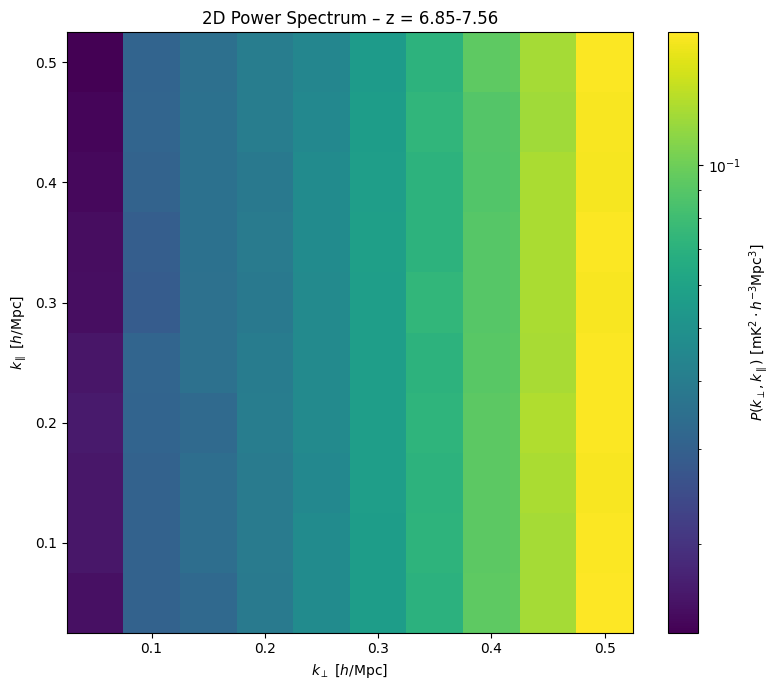

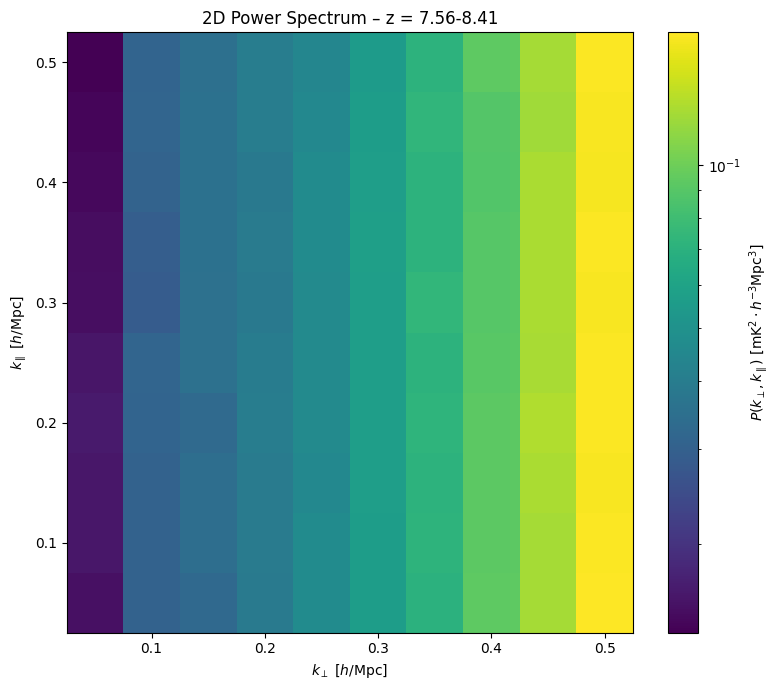

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

# Chemin vers vos résultats
output_dir = "results_simu"
files = sorted(glob.glob(f"{output_dir}/data_z_*.npz"))
ps2d_list = []
for f in files:
    # 1. Charger le fichier .npz
    container = np.load(f)
    
    # 2. Extraire les données en utilisant les clés définies lors du np.savez
    ps2d = container['ps2d']
    kperp = container['kperp']
    kpar = container['kpar']
    
    # Extraire le redshift du nom du fichier pour le titre
    # (ou vous pouvez l'ajouter dans le np.savez lors de la simulation)
    z_str = f.split('_z_')[-1].replace('.npz', '')

    plt.figure(figsize=(8, 7))
    
    # 3. Affichage
    # Note : pcolormesh prend souvent les bords des bins. 
    # Si kperp et kpar sont les centres, le rendu sera correct avec shading='auto'
    fonction = ps2_average_noise_list[i]
    ps2d_list.append(fonction)
    pcm = plt.pcolormesh(kperp, kpar, fonction, 
                         norm=LogNorm(vmin=fonction[fonction > 0].min(), vmax=fonction.max()),
                         cmap='viridis',
                         shading='auto')
    
    plt.colorbar(pcm, label=r'$P(k_\perp, k_\parallel)$ [mK$^2 \cdot h^{-3} \text{Mpc}^3$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'2D Power Spectrum – z = {z_str}')
    plt.tight_layout()
    plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/Pk_PS2_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_list = []
z_ranges_list = []
for i, f in enumerate(files):

    data = np.loadtxt(f)
    ps2_true_list.append(data)
    z_ranges_list.append(z_ranges[i])

In [5]:
ps2d_pred = np.array(ps2d_list).flatten()
ps2_true = np.array(ps2_true_list).flatten()
ps2_std = (np.array(ps2_true_err_list)).flatten()

In [8]:
def compute_sigma():
    return ps2_std

def log_likelihood(y_true, y_pred):
    sigma = compute_sigma()
    chi_square_vec = y_true - y_pred
    norm = 1.0 / np.sqrt((2 * np.pi) ** len(sigma) * np.prod(sigma ** 2))
    exponent = -0.5 * np.sum((chi_square_vec / sigma) ** 2)
    return exponent   

In [9]:
log_likelihood(ps2_true, ps2d_pred)

/tmp/ipykernel_890431/2760000367.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  norm = 1.0 / np.sqrt((2 * np.pi) ** len(sigma) * np.prod(sigma ** 2))


np.float64(-8187.246547041153)